In [ ]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

# plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [31]:
to_compare = ["kria_openssl", "kria_swtpm", "kria_tpm", "rpi_openssl", "ubuntu_openssl", "ubuntu_swtpm"]
file_path = "./pipeline/data/{device}/resource_usage.csv"

combined_list = []
for file in to_compare:
    if "vm" in file or "ubuntu" in file:
        continue

    try:
        df = pd.read_csv(file_path.format(device=file), parse_dates=["timestamp"])
        print(f"{file}: {df.shape}")

        dev, type_ = file.split("_")
        df["device"] = dev.replace("ubuntu", "vm")
        df["type"] = type_
        df["device_type"] = file.replace("ubuntu", "vm")

        combined_list.append(df)
    except FileNotFoundError:
        continue
    except Exception as err:
        print(str(err))

if combined_list:
    combined_df = pd.concat(combined_list).sort_values(by=["device_type"], ignore_index=True)
else:
    combined_df = pd.DataFrame()

print(f"Combined: {combined_df.shape}")

kria_openssl: (124354, 4)
kria_swtpm: (150596, 4)
kria_tpm: (149918, 4)
rpi_openssl: (89541, 4)
Combined: (514409, 7)


In [32]:
combined_df.sample(30)

,timestamp,cpu_usage_percent,memory_used_mb,memory_usage_percent,device,type,device_type
46615,2025-07-19 13:45:05.734,27.44,816,20.87,kria,openssl,kria_openssl
509460,2025-07-19 17:39:34.159,25.00,478,12.61,rpi,openssl,rpi_openssl
420669,2025-07-19 15:51:41.665,0.00,725,18.55,kria,tpm,kria_tpm
225230,2025-07-19 12:38:40.638,1.19,705,18.04,kria,swtpm,kria_swtpm
445179,2025-07-19 17:42:40.489,63.69,484,12.78,rpi,openssl,rpi_openssl
265974,2025-07-19 12:47:19.838,96.31,764,19.55,kria,swtpm,kria_swtpm
23559,2025-07-19 13:37:42.894,0.00,758,19.39,kria,openssl,kria_openssl
234842,2025-07-19 12:40:12.708,0.00,750,19.19,kria,swtpm,kria_swtpm
345901,2025-07-19 16:04:17.215,80.36,733,18.76,kria,tpm,kria_tpm
224898,2025-07-19 12:38:31.419,1.19,687,17.59,kria,swtpm,kria_swtpm


=== Device Comparison Summary ===


,device_type,peak_cpu,avg_cpu,peak_mem_mb,avg_mem_mb,peak_mem_pct,avg_mem_pct
0,kria_openssl,100.00,20.458096,966,780.404137,24.72,19.967011
1,kria_swtpm,100.00,17.982826,960,757.458266,24.56,19.380406
2,kria_tpm,100.00,17.399641,933,737.178217,23.88,18.862278
3,rpi_openssl,80.48,14.184777,741,474.474542,19.56,12.528402


<Figure size 800x500 with 0 Axes>

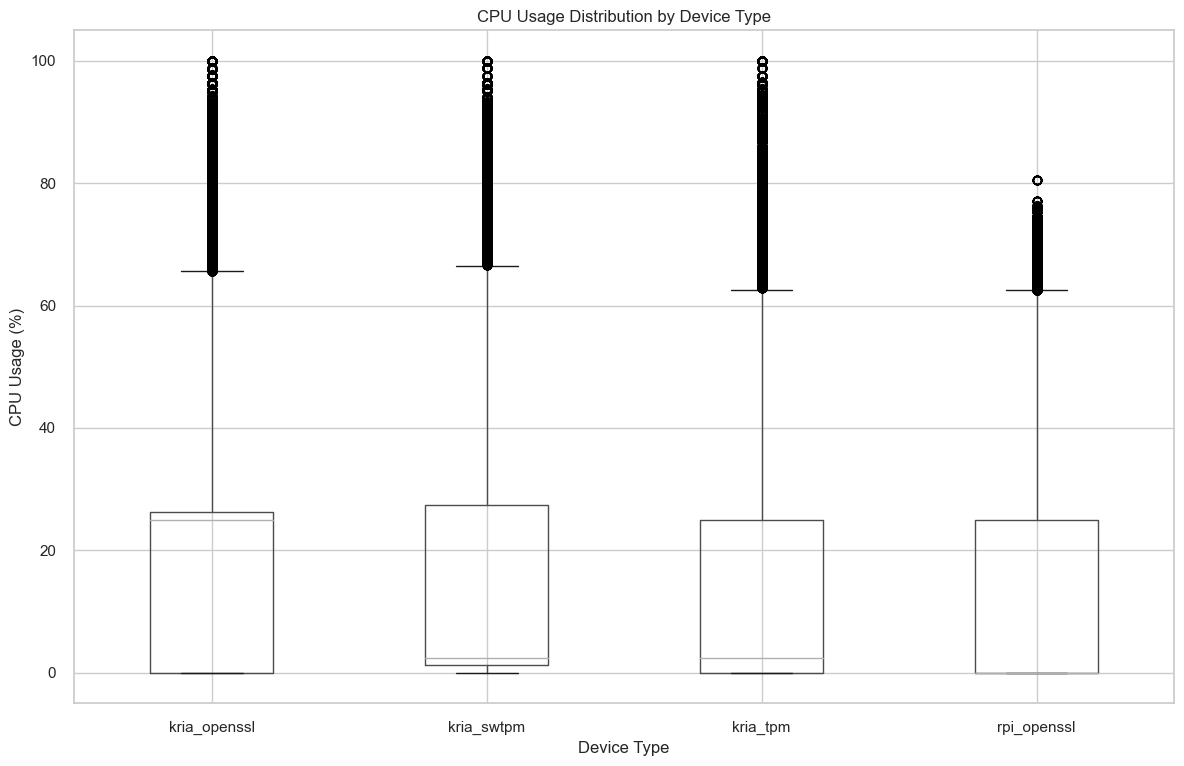

In [33]:
# summary metrics
summary = (
    combined_df.groupby("device_type")
    .agg(
        peak_cpu=("cpu_usage_percent", "max"),
        avg_cpu=("cpu_usage_percent", "mean"),
        peak_mem_mb=("memory_used_mb", "max"),
        avg_mem_mb=("memory_used_mb", "mean"),
        peak_mem_pct=("memory_usage_percent", "max"),
        avg_mem_pct=("memory_usage_percent", "mean"),
    )
    .reset_index()
)

print("=== Device Comparison Summary ===")
display(summary)

# visualise
plt.figure(figsize=(8, 5))
combined_df.boxplot(column="cpu_usage_percent", by="device_type")
plt.title("CPU Usage Distribution by Device Type")
plt.suptitle("")
plt.xlabel("Device Type")
plt.ylabel("CPU Usage (%)")
plt.tight_layout()
plt.show()
